# Additional demographic analyses

This notebook contains analyses that span multiple demographic attributes or are not restricted to gender-related questions. Distances are ordinal Wasserstein distances between model and OpinionQA response distributions.

In [10]:
import ast, json, re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr, wilcoxon

def find_repo_root(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'results' / 'demo_full.csv').is_file() and (candidate / 'analyses').is_dir(): return candidate
    raise FileNotFoundError('Could not locate the repository root.')

REPO=find_repo_root(); ANALYSIS_DATA=REPO/'analyses'/'data'
DEMO_PATH=REPO/'results'/'demo_full.csv'; OQA_PATH=REPO/'data'/'political_questions'/'OpinionQA'/'opinionqa.csv'
QDICT_PATH=REPO/'data'/'political_questions'/'OpinionQA'/'refined_qkey_dict.json'
required=[DEMO_PATH,OQA_PATH,QDICT_PATH,ANALYSIS_DATA/'human_declared_vs_real.csv',ANALYSIS_DATA/'human_steered_vs_real.csv']
for path in required:
    if not path.is_file(): raise FileNotFoundError(path)
print('Repository root:',REPO)

declared=pd.read_csv(ANALYSIS_DATA/'human_declared_vs_real.csv')
steered=pd.read_csv(ANALYSIS_DATA/'human_steered_vs_real.csv')
opp=pd.read_csv(ANALYSIS_DATA/'opposed_vs_real.csv') if (ANALYSIS_DATA/'opposed_vs_real.csv').is_file() else None
opp_summary=pd.read_csv(ANALYSIS_DATA/'opposed_follows_summary.csv') if (ANALYSIS_DATA/'opposed_follows_summary.csv').is_file() else None
ATTRIBUTES=['gender','age','education','socioeco']; neutral=steered[steered.magnitude.eq(0)].copy(); steered_n7=steered[steered.magnitude.eq(7)].copy()

with open(QDICT_PATH,encoding='utf-8') as stream: question_records=json.load(stream)
ordinals={}; question_text={}
for qkey,record in question_records.items():
    options=[option for option in record['options'] if option!='Refused']
    ordinals[qkey]=np.asarray(record.get('ordinal',range(1,len(options)+1)),float)
    question_text[qkey]=record.get('original_qbody',record.get('refined_qbody',''))
def normalize(values):
    values=np.asarray(values,float); total=values.sum(); return values/total if total>0 else values
def align(values,size):
    values=np.asarray(values,float); return normalize(values[:size] if len(values)>size else values)
def wasserstein_ordinal(left,right,ordinal):
    size=len(ordinal); left,right=align(left,size),align(right,size); order=np.argsort(ordinal,kind='stable'); positions=ordinal[order]
    gap=np.abs(np.cumsum(left[order])-np.cumsum(right[order])); return float(np.sum(gap[:-1]*np.diff(positions)))

demo=pd.read_csv(DEMO_PATH); demo['dist']=demo.response_distribution.apply(json.loads)
HUMAN={}
for _,row in pd.read_csv(OQA_PATH).iterrows(): HUMAN[(row.qkey,row.attribute,row.group)]=np.asarray(ast.literal_eval(row.responses),float)
print('Declared:',declared.shape,'Steered:',steered.shape,'Opposed:',None if opp is None else opp.shape)


Repository root: C:\Users\mario\OneDrive - csr.ufmg.br\Documents\GitHub\internal_LLM_bias
Declared: (4931, 8) Steered: (34517, 8) Opposed: (23640, 9)


## 1. Distance to human groups with 95% confidence intervals

The bars compare the neutral baseline, declared profiles, and N=7 steering for each model class.

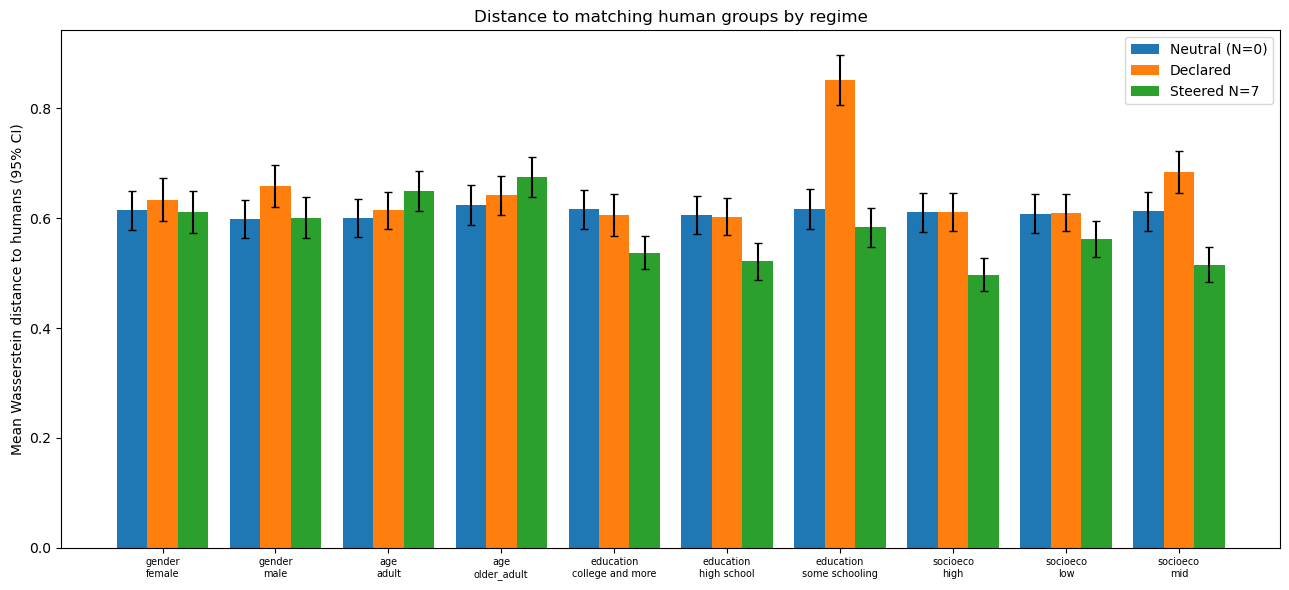

In [11]:
def mean_ci(values):
    values=np.asarray(values,float); n=len(values); mean=values.mean(); ci=1.96*values.std(ddof=1)/np.sqrt(n) if n>1 else 0
    return mean,ci
rows=[]
for attribute in ATTRIBUTES:
    classes=sorted(declared[declared.attribute.eq(attribute)].class_label.unique())
    for model_class in classes:
        for regime,frame in [('Neutral (N=0)',neutral),('Declared',declared),('Steered N=7',steered_n7)]:
            values=frame[frame.attribute.eq(attribute)&frame.class_label.eq(model_class)].wasserstein
            if len(values): rows.append((f'{attribute}\n{model_class}',regime,*mean_ci(values)))
summary_ci=pd.DataFrame(rows,columns=['group','regime','mean','ci']); labels=list(dict.fromkeys(summary_ci.group)); x=np.arange(len(labels)); width=.27
fig,ax=plt.subplots(figsize=(13,6))
for index,regime in enumerate(['Neutral (N=0)','Declared','Steered N=7']):
    values=summary_ci[summary_ci.regime.eq(regime)].set_index('group').reindex(labels)
    ax.bar(x+(index-1)*width,values['mean'],width,yerr=values['ci'],capsize=3,label=regime)
ax.set_xticks(x,labels,fontsize=7); ax.set_ylabel('Mean Wasserstein distance to humans (95% CI)'); ax.set_title('Distance to matching human groups by regime'); ax.legend(); plt.tight_layout(); plt.show()


## 2. Paired significance tests against the neutral baseline

Wilcoxon signed-rank tests pair conditions by question, attribute, and class. Negative mean deltas indicate improvement over the neutral model.

In [12]:
def paired(left,right,keys=('qkey','attribute','class_label')):
    merged=left.merge(right,on=list(keys),suffixes=('_left','_right')); return merged.wasserstein_left.values,merged.wasserstein_right.values
tests=[]
for attribute in ATTRIBUTES:
    baseline=neutral[neutral.attribute.eq(attribute)]
    for regime,frame in [('Declared',declared[declared.attribute.eq(attribute)]),('Steered N=7',steered_n7[steered_n7.attribute.eq(attribute)])]:
        condition,control=paired(frame,baseline)
        if len(condition)<10: continue
        delta=float(np.mean(condition-control))
        try: p_value=wilcoxon(condition,control).pvalue
        except ValueError: p_value=np.nan
        tests.append((attribute,regime,len(condition),delta,p_value,'closer' if delta<0 else 'farther'))
pd.DataFrame(tests,columns=['attribute','regime','n','delta_vs_neutral','p_value','direction']).round(4)


,attribute,regime,n,delta_vs_neutral,p_value,direction
0,gender,Declared,986,0.0394,0.0000,farther
1,gender,Steered N=7,986,-0.0005,0.8141,closer
2,age,Declared,981,0.0161,0.2342,farther
3,age,Steered N=7,981,0.0499,0.0010,farther
4,education,Declared,1482,0.0739,0.0000,farther
5,education,Steered N=7,1482,-0.0655,0.0000,closer
6,socioeco,Declared,1482,0.0248,0.0123,farther
7,socioeco,Steered N=7,1482,-0.0855,0.0000,closer


## 3. Which steering magnitude best matches human responses?

The magnitude that maximizes class separation need not minimize distance to human subgroup distributions.

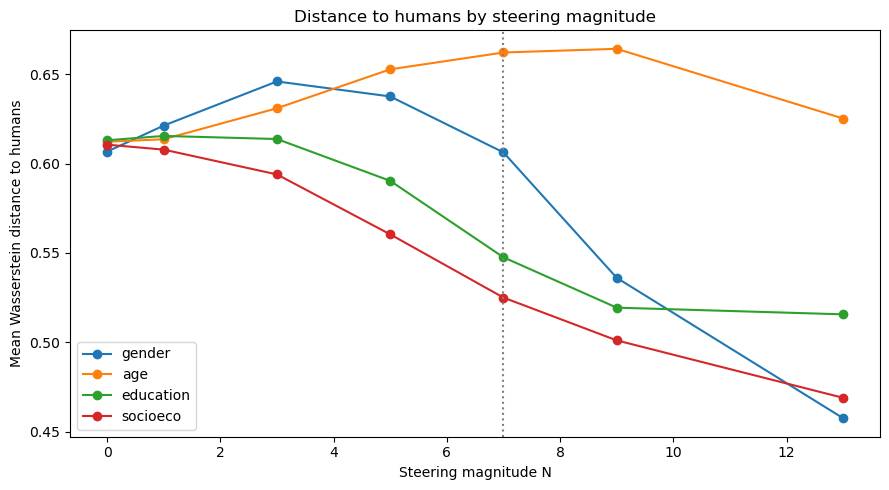

,attribute,best_magnitude,distance_at_best,distance_at_n7
0,gender,13.0,0.4575,0.6062
1,age,0.0,0.6122,0.6621
2,education,13.0,0.5157,0.5475
3,socioeco,13.0,0.4689,0.5250


In [13]:
curve=steered.groupby(['attribute','magnitude']).wasserstein.mean().reset_index(); best=[]; fig,ax=plt.subplots(figsize=(9,5))
for attribute in ATTRIBUTES:
    values=curve[curve.attribute.eq(attribute)].sort_values('magnitude'); ax.plot(values.magnitude,values.wasserstein,marker='o',label=attribute)
    optimum=values.loc[values.wasserstein.idxmin()]; n7=values[values.magnitude.eq(7)].wasserstein.iloc[0]
    best.append((attribute,optimum.magnitude,optimum.wasserstein,n7))
ax.axvline(7,ls=':',color='gray'); ax.set(xlabel='Steering magnitude N',ylabel='Mean Wasserstein distance to humans',title='Distance to humans by steering magnitude'); ax.legend(); plt.tight_layout(); plt.show()
pd.DataFrame(best,columns=['attribute','best_magnitude','distance_at_best','distance_at_n7']).round(4)


## 4. Opposed profiles: declared prompt versus steering direction

These plots test whether a response is closer to the human group named in the prompt or to the group targeted by the opposing steering vector.

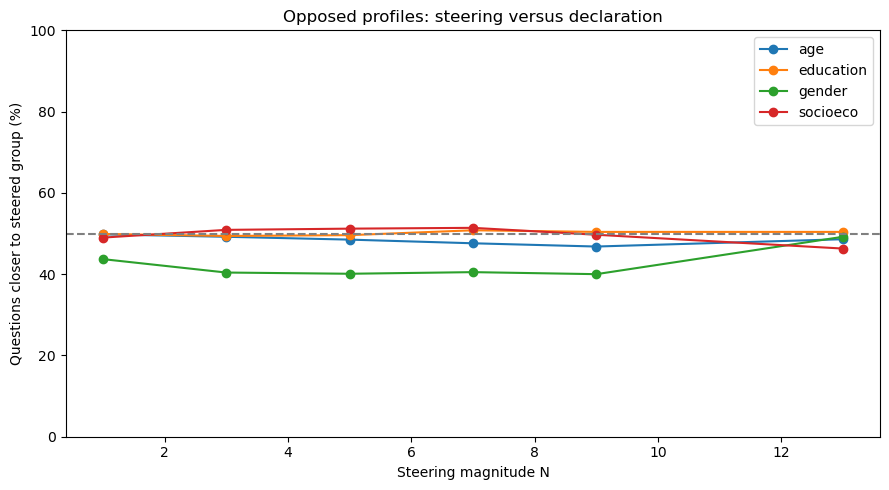

magnitude,1.0,3.0,5.0,7.0,9.0,13.0
attribute,,,,,,
age,49.8,49.2,48.5,47.6,46.8,48.6
education,49.9,49.4,49.6,50.8,50.4,50.4
gender,43.7,40.4,40.1,40.5,40.0,49.2
socioeco,49.0,50.9,51.2,51.4,49.7,46.3


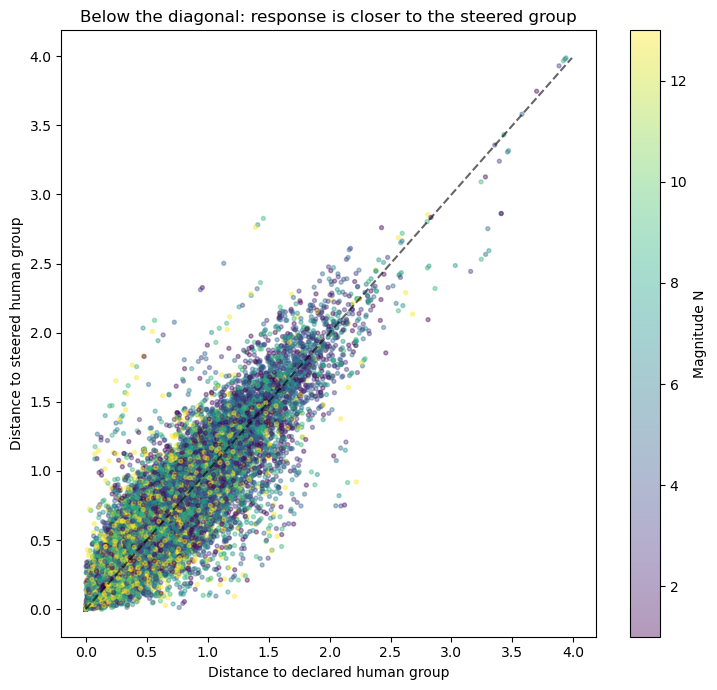

In [14]:
if opp_summary is not None:
    fig,ax=plt.subplots(figsize=(9,5))
    for attribute in sorted(opp_summary.attribute.unique()):
        values=opp_summary[opp_summary.attribute.eq(attribute)].sort_values('magnitude'); ax.plot(values.magnitude,values.pct_follows_steered,marker='o',label=attribute)
    ax.axhline(50,ls='--',color='gray'); ax.set_ylim(0,100); ax.set(xlabel='Steering magnitude N',ylabel='Questions closer to steered group (%)',title='Opposed profiles: steering versus declaration'); ax.legend(); plt.tight_layout(); plt.show()
    display(opp_summary.pivot_table(index='attribute',columns='magnitude',values='pct_follows_steered'))
else: print('opposed_follows_summary.csv is unavailable')

if opp is not None:
    fig,ax=plt.subplots(figsize=(7.5,7)); scatter=ax.scatter(opp.dist_to_real_declared,opp.dist_to_real_steered,c=opp.magnitude,cmap='viridis',s=8,alpha=.4)
    limit=float(np.nanmax([opp.dist_to_real_declared.max(),opp.dist_to_real_steered.max()])); ax.plot([0,limit],[0,limit],'k--',alpha=.6)
    ax.set(xlabel='Distance to declared human group',ylabel='Distance to steered human group',title='Below the diagonal: response is closer to the steered group'); plt.colorbar(scatter,label='Magnitude N'); plt.tight_layout(); plt.show()


## 5. Questions most improved by N=7 steering

Improvement is the neutral distance minus the N=7 distance. Positive values indicate that steering moved the model closer to the matching human group.

In [15]:
merged=steered_n7.merge(neutral,on=['qkey','attribute','class_label'],suffixes=('_steered','_neutral')); merged['improvement']=merged.wasserstein_neutral-merged.wasserstein_steered
for attribute in ATTRIBUTES:
    print(f'\n{attribute}: largest improvements')
    for _,row in merged[merged.attribute.eq(attribute)].nlargest(5,'improvement').iterrows():
        print(f"  +{row.improvement:.3f}  {row.class_label:14s} {row.qkey:16s} {question_text.get(row.qkey,'')[:75]}")



gender: largest improvements
  +1.590  male           FAMSURV32e_W50   How do you feel about each of the following? Your spouse's/partner's approa
  +1.553  male           S13_W29          This next question is about friends and family you do not live with. During
  +1.285  female         INFOCREATEa_W45  How much made-up news and information do you think is created by…Journalist
  +1.223  male           ROMRELSER_W50    How serious would you say your current romantic relationship is?
  +1.193  male           GAP21Q34_b_W82   Thinking about Joe Biden’s ability to handle a number of things, how confid

age: largest improvements
  +1.195  older_adult    GOVPRIORITYf_W54 How much of a priority should each of the following be for the federal gove
  +1.152  older_adult    FAMSURV32e_W50   How do you feel about each of the following? Your spouse's/partner's approa
  +1.115  adult          ECON5_d_W54      Do you think the country’s current economic conditions are helping or hurti
  +1.112  

## 6. Model subgroup gaps versus human subgroup gaps

Extreme class contrasts are evaluated for all four attributes. Positive mean delta indicates that the model exaggerates the average human subgroup gap.

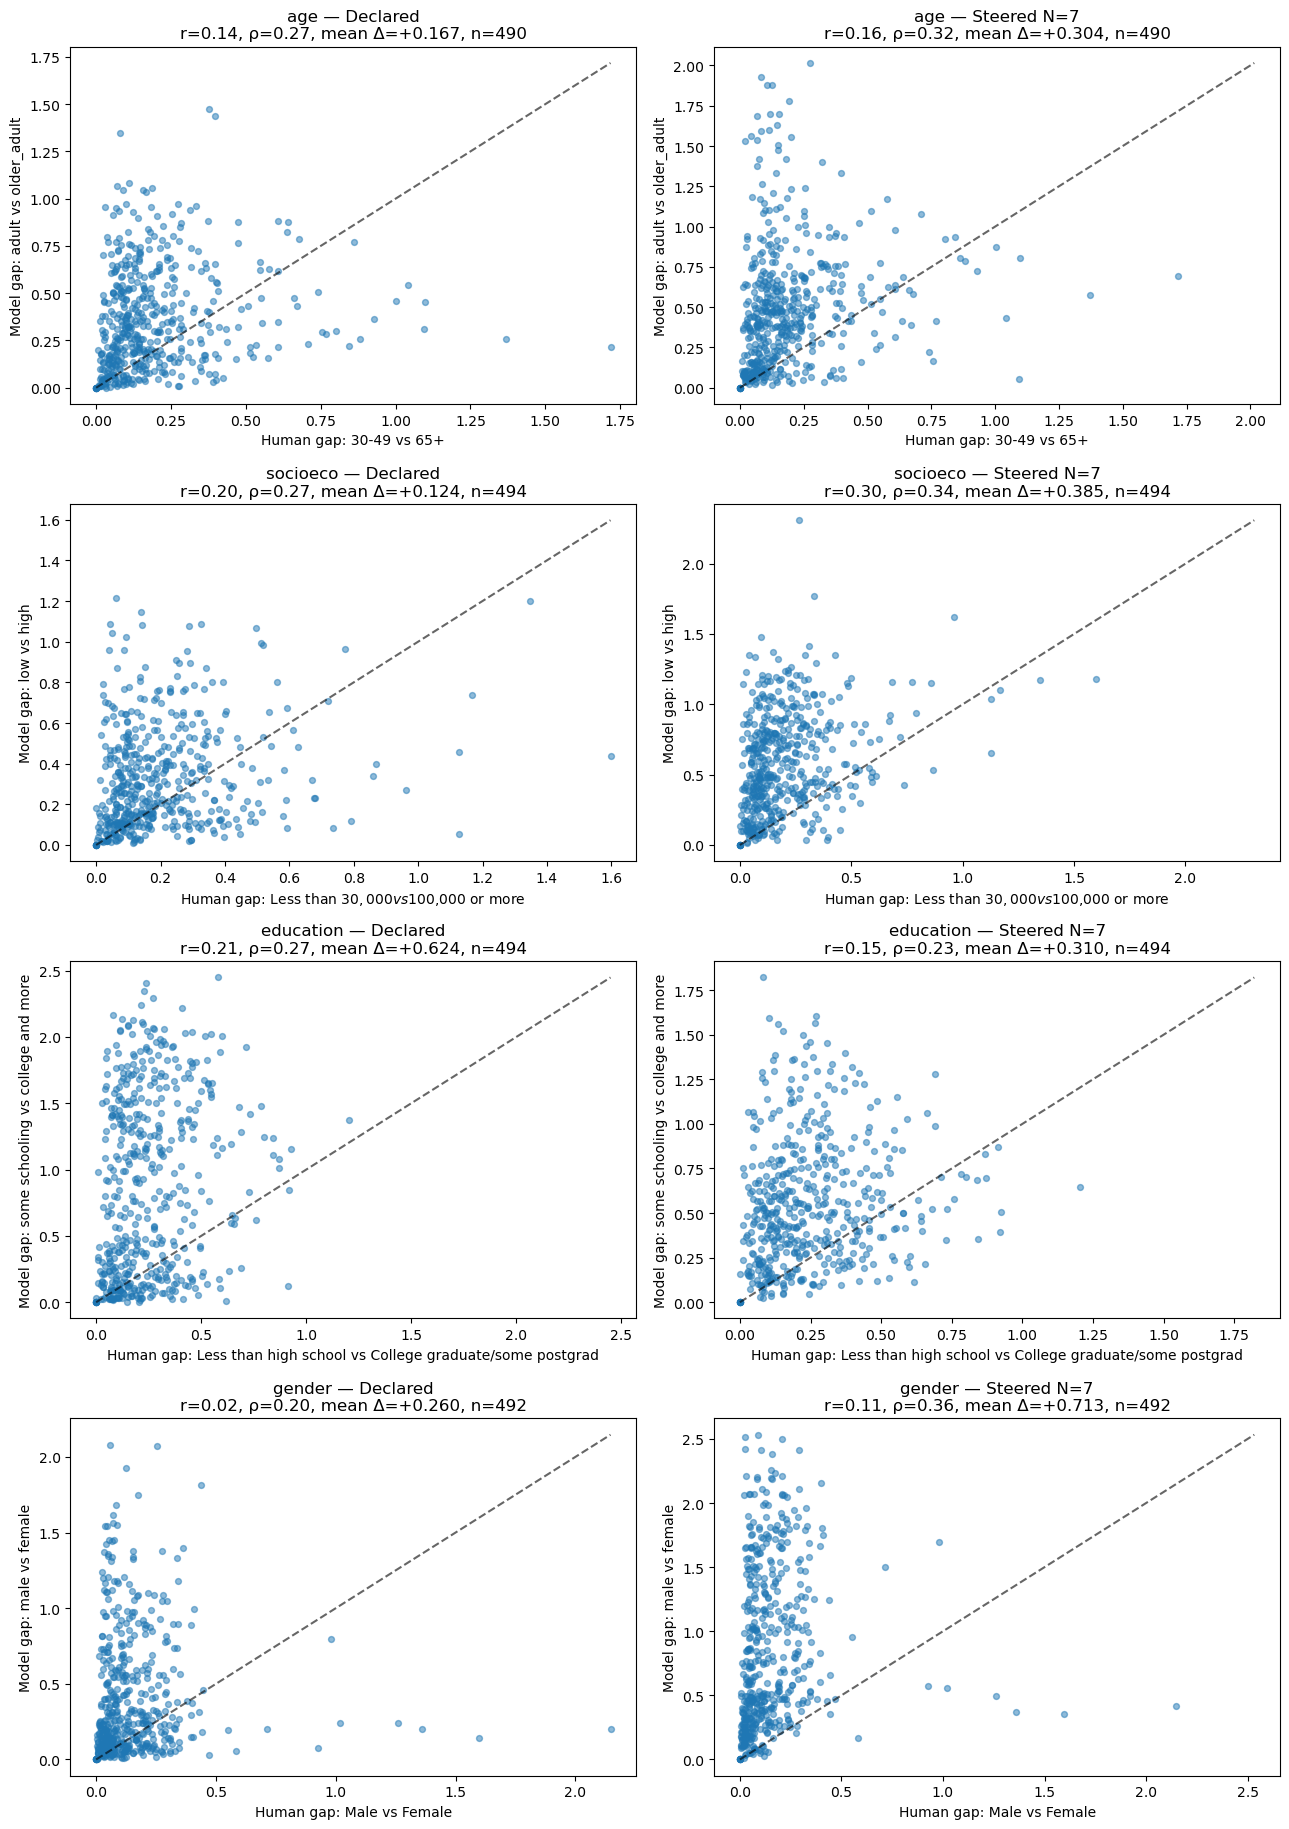

,attribute,channel,n,pearson,spearman,mean_delta
0,age,declared,490,0.145,0.272,0.167
1,age,steered,490,0.160,0.321,0.304
2,socioeco,declared,494,0.204,0.268,0.124
3,socioeco,steered,494,0.299,0.340,0.385
4,education,declared,494,0.209,0.268,0.624
5,education,steered,494,0.150,0.231,0.310
6,gender,declared,492,0.017,0.205,0.260
7,gender,steered,492,0.107,0.360,0.713


In [16]:
PAIRS={'age':('AGE',('adult','older_adult'),('30-49','65+')),'socioeco':('INCOME',('low','high'),('Less than $30,000','$100,000 or more')),'education':('EDUCATION',('some schooling','college and more'),('Less than high school','College graduate/some postgrad')),'gender':('SEX',('male','female'),('Male','Female'))}
def model_gap(attribute,class_a,class_b,channel,magnitude):
    subset=demo[demo.attribute.eq(attribute)&demo.channel.eq(channel)]; subset=subset[subset.magnitude.isna()] if channel=='declared' else subset[subset.magnitude.eq(magnitude)]; output={}
    for qkey,group in subset.groupby('qkey'):
        distributions={row.class_label:row.dist for row in group.itertuples()}
        if class_a in distributions and class_b in distributions and qkey in ordinals: output[qkey]=wasserstein_ordinal(distributions[class_a],distributions[class_b],ordinals[qkey])
    return output
def human_gap(attribute,group_a,group_b):
    output={}
    for qkey in ordinals:
        key_a,key_b=(qkey,attribute,group_a),(qkey,attribute,group_b)
        if key_a in HUMAN and key_b in HUMAN and len(HUMAN[key_a])==len(ordinals[qkey])==len(HUMAN[key_b]): output[qkey]=wasserstein_ordinal(HUMAN[key_a],HUMAN[key_b],ordinals[qkey])
    return output
fig,axes=plt.subplots(len(PAIRS),2,figsize=(13,4.6*len(PAIRS))); correlation_rows=[]
for row_index,(attribute,(oqa_attribute,(class_a,class_b),(group_a,group_b))) in enumerate(PAIRS.items()):
    human=human_gap(oqa_attribute,group_a,group_b)
    for column_index,(channel,magnitude,title) in enumerate([('declared',None,'Declared'),('steered',7.0,'Steered N=7')]):
        model=model_gap(attribute,class_a,class_b,channel,magnitude); common=[qkey for qkey in model if qkey in human]; x=np.asarray([human[q] for q in common]); y=np.asarray([model[q] for q in common]); ax=axes[row_index,column_index]
        ax.scatter(x,y,alpha=.5,s=18); limit=max(x.max() if len(x) else 1,y.max() if len(y) else 1); ax.plot([0,limit],[0,limit],'k--',alpha=.6)
        pearson=pearsonr(x,y).statistic if len(x)>2 and np.std(x)>0 and np.std(y)>0 else np.nan; spearman=spearmanr(x,y).statistic if len(x)>2 else np.nan; mean_delta=float(np.mean(y-x)) if len(x) else np.nan
        ax.set(title=f'{attribute} — {title}\nr={pearson:.2f}, ρ={spearman:.2f}, mean Δ={mean_delta:+.3f}, n={len(x)}',xlabel=f'Human gap: {group_a} vs {group_b}',ylabel=f'Model gap: {class_a} vs {class_b}'); correlation_rows.append((attribute,channel,len(x),pearson,spearman,mean_delta))
plt.tight_layout(); plt.show(); pd.DataFrame(correlation_rows,columns=['attribute','channel','n','pearson','spearman','mean_delta']).round(3)
